# 08 Leakage and Time (E-31 to E-34)

**Data used:** the development set. The sale-outcome price context is descriptive only; `SaleType` and `SaleCondition` are never model features (ADR-02).  
**Questions:** Q18 listing-time availability, Q19 time (DOC-02 §4.6, §4.7). Notebook 07 is reserved for M4.

All computation lives in `house_price.eda` (FR-010): this notebook only runs it and shows the saved outputs (`reports/eda/`, `reports/figures/eda/`).

In [1]:
from IPython.display import Image, Markdown, display

from house_price.eda import EDAContext
from house_price.eda import leakage_time

ctx = EDAContext.load()  # validated raw file + persisted development set (never the held-out rows)

In [2]:
outputs = leakage_time.run(ctx)
sorted(outputs.tables) + sorted(outputs.figures)

['E-31_leakage_review',
 'E-31_sale_outcome_context',
 'E-32_sale_years',
 'E-33_price_by_year',
 'E-34_seasonality',
 'E-32_sale_years',
 'E-33_price_by_year',
 'E-34_seasonality']

## E-31 Leakage review and descriptive sale-outcome context.

In [3]:
outputs.tables["E-31_leakage_review"]

,column,known_at_listing,decision,reason
0,YrSold,"yes, as the valuation year",kept,Valuation year; needed for ages (ADR-02)
1,MoSold,"yes, as the valuation month",kept,Kept as provided (DOC-02 §11.6)
2,SaleType,no,excluded,Legal/financial form of the completed transact...
3,SaleCondition,no,excluded,Circumstances of the completed sale (for examp...
4,Id,not a property attribute,excluded,Record identifier (IN-03)
5,PID,not a property attribute,excluded,Parcel identifier (IN-03)


In [4]:
outputs.tables["E-31_sale_outcome_context"]

,column,level,n,median_log_price,difference_vs_overall_median
0,SaleCondition,AdjLand,8,11.607873,-0.375063
1,SaleCondition,Abnorml,154,11.747935,-0.235000
2,SaleCondition,Family,40,11.821519,-0.161416
3,SaleCondition,Alloca,17,11.924439,-0.058496
4,SaleCondition,Normal,1929,11.976666,-0.006270
5,SaleCondition,Partial,192,12.430379,0.447444
6,SaleType,ConLw,6,11.613997,-0.368938
7,SaleType,Oth,7,11.661785,-0.321150
8,SaleType,ConLI,9,11.686887,-0.296048
9,SaleType,COD,73,11.755879,-0.227056


## E-32 Sales per year (2010 covers January-July only).

In [5]:
outputs.tables["E-32_sale_years"]

,YrSold,n,first_month,last_month
0,2006,491,1,12
1,2007,564,1,12
2,2008,490,1,12
3,2009,517,1,12
4,2010,278,1,7


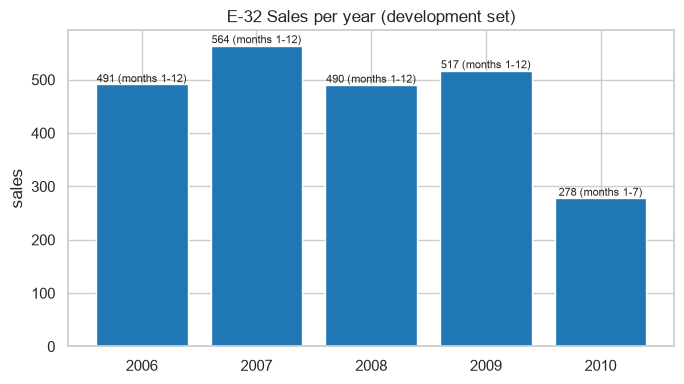

In [6]:
Image(filename=outputs.figures["E-32_sale_years"])

## E-33 Median log price by year.

In [7]:
outputs.tables["E-33_price_by_year"]

,YrSold,n,median_log_price
0,2006,491,11.982935
1,2007,564,12.031725
2,2008,490,11.984495
3,2009,517,11.982935
4,2010,278,11.948924


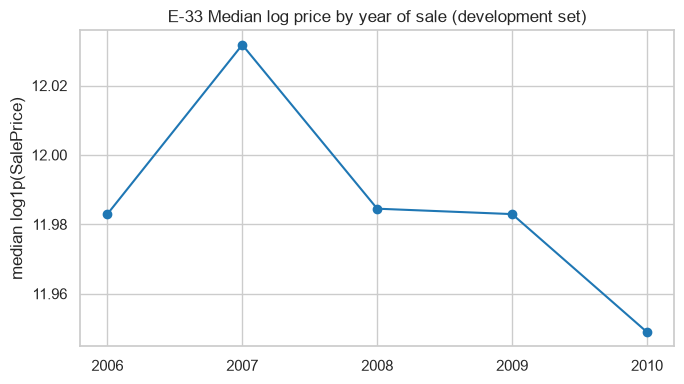

In [8]:
Image(filename=outputs.figures["E-33_price_by_year"])

## E-34 Seasonality by month.

In [9]:
outputs.tables["E-34_seasonality"]

,MoSold,n,median_log_price
0,1,93,11.982935
1,2,102,12.034657
2,3,183,11.982935
3,4,226,11.957453
4,5,315,11.964007
5,6,410,11.967187
6,7,361,11.982310
7,8,188,12.009141
8,9,134,12.100718
9,10,139,11.964007


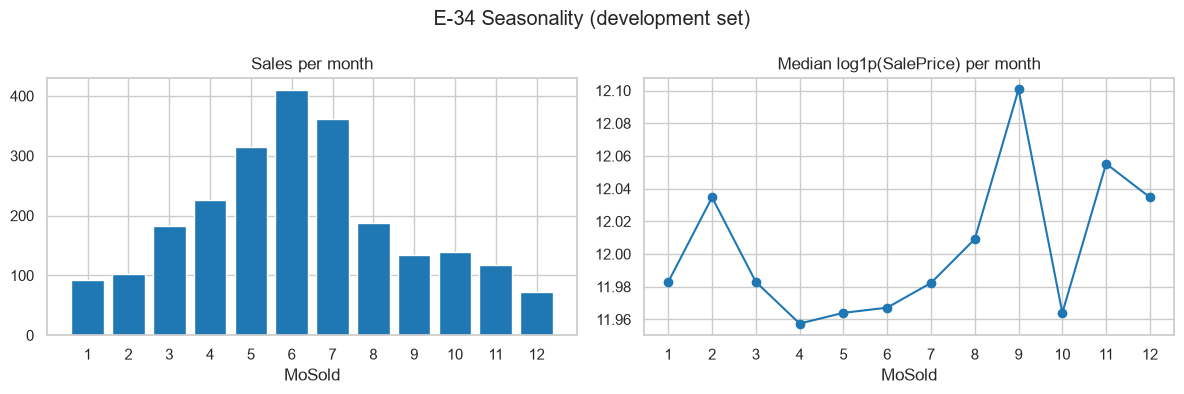

In [10]:
Image(filename=outputs.figures["E-34_seasonality"])